# Trabalho Prático 1 - Aprendizagem Automática
## Previsão de Preços de Carros Usados (Kaggle Competition)

**Licenciatura em Engenharia de Sistemas e Tecnologias Informáticas** 
**Unidade Curricular:** Aprendizagem Automática  
**Ano Letivo:** 2025/2026 

---

### 1. Introdução e Objetivos
Este *notebook* documenta o processo de desenvolvimento de modelos de Aprendizagem Automática para prever o preço de carros usados, no âmbito da competição Kaggle da disciplina. O objetivo principal é desenvolver um modelo de regressão robusto capaz de estimar o valor de mercado de veículos com base nas suas características (e.g., marca, modelo, motorização, quilometragem).

A metodologia adotada foca-se na **correção de problemas de imputação de dados** detetados em iterações anteriores, na **engenharia de atributos** e na utilização de **técnicas de Ensemble Learning**.

### 2. Identificação do Grupo
* **Aluno 1:** Bernardo Freitas (79295)
* **Aluno 2:** Afonso Figueiredo (79309)

### 3. Descrição da Abordagem
Esta versão introduz uma correção crítica no fluxo de processamento de dados para resolver o erro `Input X contains NaN`. A arquitetura foi reestruturada utilizando **Pipelines do Scikit-Learn**, garantindo que todas as etapas de pré-processamento (imputação, normalização) são executadas de forma consistente dentro da validação cruzada.

**Estratégia Implementada:**
1.  **Imputação Hierárquica:** Preenchimento de valores em falta baseado na marca do veículo.
2.  **Pipeline Integrado:** Cada modelo (XGBoost, Random Forest, Gradient Boosting) é encapsulado num pipeline que inclui imputação e escalonamento.
3.  **Ensemble Ponderado:** Combinação das previsões de múltiplos modelos para reduzir a variância e melhorar a generalização.

### 4. Configuração do Ambiente e Importação de Bibliotecas
Nesta secção, importam-se as bibliotecas fundamentais para a manipulação de dados (`pandas`, `numpy`) e modelação (`sklearn`, `xgboost`). Define-se também a configuração global do ambiente, permitindo alternar entre um modo de execução rápida (`quick`) para depuração e um modo completo (`full`) para o treino final dos modelos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os, joblib, re, random

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

# --- CONFIGURAÇÃO GLOBAL ---
MODE = 'full'  # 'quick' para testes rápidos ou 'full' para produção
TRAIN_N_JOBS = -1
RANDOM_STATE = 42

# Definição de parâmetros baseada no modo de execução
if MODE == 'quick':
    CV_FOLDS = 3
    N_ITER = 2
    XGB_ESTIMATORS = 100
else:
    CV_FOLDS = 5
    N_ITER = 15
    XGB_ESTIMATORS = 3000

os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print(f"Ambiente Pronto. Modo: {MODE} | N_Jobs: {TRAIN_N_JOBS}")

Ambiente Pronto. Modo: full | N_Jobs: -1


### 5. Pré-processamento e Engenharia de Atributos
O pré-processamento é uma etapa crucial para garantir a qualidade dos dados. Nesta fase, são aplicadas as seguintes transformações:

1.  **Limpeza e Extração de Dados (`clean_engine`):** A coluna `engine` contém informação não estruturada. Utilizam-se expressões regulares (Regex) para extrair a potência (HP), a cilindrada (Liters) e o número de cilindros.
2.  **Normalização de Categorias (`map_transmission`):** Simplificação das categorias de transmissão para grupos principais (Automático, Manual, CVT).
3.  **Tratamento de Valores Omissos (Imputação):** Aplica-se uma estratégia de imputação baseada no domínio. Valores em falta de `HP` e `Liters` são preenchidos utilizando a mediana calculada por **marca** (`brand`), em vez da mediana global, preservando as características específicas de cada fabricante.
4.  **Criação de Novos Atributos:**
    * `age`: Idade do veículo calculada a partir do ano de fabrico.
    * `hp_per_liter`: Rácio de performance do motor.
    * `is_super_luxury`: Indicador binário para marcas de luxo.
5.  **Codificação de Variáveis Categóricas:** Conversão de variáveis textuais em numéricas utilizando `LabelEncoder`.

In [2]:
# Carregar Dados
try:
    train_df = pd.read_csv('../data/train.csv')
    test_df = pd.read_csv('../data/test.csv')
except:
    print("Erro: Verifique os ficheiros csv.")

# --- LIMPEZA E EXTRAÇÃO ---
def clean_engine(row):
    engine = str(row['engine'])
    hp, liters, cylinders = np.nan, np.nan, np.nan
    
    # Extração via Regex
    hp_match = re.search(r'(\d+\.?\d*)HP', engine)
    if hp_match: hp = float(hp_match.group(1))
    
    lit_match = re.search(r'(\d+\.?\d*)L', engine)
    if not lit_match: lit_match = re.search(r'(\d+\.?\d*) Liter', engine)
    if lit_match: liters = float(lit_match.group(1))
    
    cyl_match = re.search(r'V(\d+)', engine)
    if not cyl_match: cyl_match = re.search(r'(\d+) Cylinder', engine)
    if cyl_match: cylinders = float(cyl_match.group(1))
    
    return pd.Series([hp, liters, cylinders])

def map_transmission(trans):
    t = str(trans).lower()
    if 'auto' in t or 'a/t' in t: return 'Automatic'
    if 'manual' in t or 'm/t' in t: return 'Manual'
    if 'cvt' in t: return 'CVT'
    return 'Other'

def clean_df(df):
    data = df.copy()
    # 1. Normalizar Mileage
    if 'mileage' in data.columns:
        if data['mileage'].dtype == 'O':
             data['milage'] = data['mileage'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0].astype(float)
        else:
             data['milage'] = data['mileage']
        if 'milage' != 'mileage':
            data.drop(columns=['mileage'], inplace=True, errors='ignore')
    elif 'milage' in data.columns:
        if data['milage'].dtype == 'O':
            data['milage'] = data['milage'].astype(str).str.replace(',', '').str.extract(r'(\d+)')[0].astype(float)
        
    # 2. Extração Motor
    data[['HP', 'Liters', 'Cylinders']] = data.apply(clean_engine, axis=1)
    # 3. Idade
    data['age'] = 2025 - pd.to_numeric(data['model_year'], errors='coerce')
    # 4. Transmissão
    data['transmission_grp'] = data['transmission'].apply(map_transmission)
    
    return data

train_df = clean_df(train_df)
test_df = clean_df(test_df)

# --- IMPUTAÇÃO POR MARCA ---
brand_hp_map = train_df.groupby('brand')['HP'].median()
brand_lit_map = train_df.groupby('brand')['Liters'].median()
global_hp = train_df['HP'].median()
global_lit = train_df['Liters'].median()

def smart_fill(row, col, mapping, glob):
    if pd.isna(row[col]):
        return mapping.get(row['brand'], glob)
    return row[col]

for df in [train_df, test_df]:
    df['HP'] = df.apply(lambda x: smart_fill(x, 'HP', brand_hp_map, global_hp), axis=1)
    df['Liters'] = df.apply(lambda x: smart_fill(x, 'Liters', brand_lit_map, global_lit), axis=1)
    for c in ['Cylinders', 'milage']:
        df[c] = df[c].fillna(train_df[c].median())
    
    df['log_milage'] = np.log1p(df['milage'])
    df['hp_per_liter'] = df['HP'] / df['Liters'].replace(0, 1.0)
    
    luxury = ['Bugatti','Lamborghini','Ferrari','McLaren','Rolls-Royce','Bentley','Aston Martin','Porsche','Maserati']
    df['is_super_luxury'] = df['brand'].isin(luxury).astype(int)

# --- LABEL ENCODING ---
cat_cols = ['brand', 'model', 'fuel_type', 'transmission_grp', 'ext_col', 'int_col', 'accident', 'clean_title']
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)
    full_data = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(full_data)
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

print("Limpeza e Engenharia Concluídas.")

Limpeza e Engenharia Concluídas.


### 6. Definição do Pipeline de Modelação
A arquitetura do pipeline foi desenhada para garantir a robustez e reprodutibilidade do modelo. 

1.  **Transformação de Variáveis:**
    * O `ColumnTransformer` aplica um `Pipeline` numérico a todas as *features*.
    * Este pipeline secundário executa um `SimpleImputer` (preenchendo eventuais valores nulos remanescentes com a mediana) e um `RobustScaler` (para normalizar os dados e reduzir o impacto de *outliers*).

2.  **Divisão dos Dados:** Separação do conjunto de treino em treino (80%) e validação (20%) para avaliação preliminar.
3.  **Variável Alvo:** Aplicação de transformação logarítmica (`log1p`) ao preço (`price`) para normalizar a distribuição dos dados e melhorar a performance dos algoritmos de regressão.

In [3]:
# --- DEFINIÇÃO DO PIPELINE E FEATURES ---
features = ['brand', 'model', 'age', 'log_milage', 'HP', 'Liters', 'Cylinders', 'hp_per_liter',
            'fuel_type', 'transmission_grp', 'ext_col', 'int_col', 'accident', 'clean_title', 'is_super_luxury']

X = train_df[features]
y = np.log1p(train_df['price'])

numeric_feats = ['age', 'log_milage', 'HP', 'Liters', 'Cylinders', 'hp_per_liter']
# Nota: Como já fizemos LabelEncoding, tratamos as categóricas como numéricas ou passamos direto.
# Mas para garantir robustez (e evitar o erro de NaN), passamos tudo pelo Imputer.

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', RobustScaler())
        ]), features)
    ])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("Split de dados concluído.")

Split de dados concluído.


### 7. Treino e Otimização de Hiperparâmetros
Foram selecionados três algoritmos de regressão distintos para compor o *ensemble* final:

1.  **XGBoost (eXtreme Gradient Boosting):** Conhecido pela sua eficiência e desempenho em dados tabulares.
2.  **Random Forest:** Algoritmo de *bagging* robusto, eficaz na redução de *overfitting*.
3.  **Gradient Boosting Regressor (sklearn):** Utilizado para diversificar a abordagem de *boosting*.

O processo de treino utiliza `RandomizedSearchCV` para encontrar a melhor combinação de hiperparâmetros para cada modelo, utilizando validação cruzada (`KFold`) para garantir a estabilidade das métricas de erro.

In [4]:
models = []

# Nota: O prefixo 'model__' é necessário porque o modelo está dentro de um Pipeline chamado 'model'

# 1. XGBoost
xgb_pipe = Pipeline([('pre', preprocessor), ('model', XGBRegressor(objective='reg:squarederror', n_jobs=TRAIN_N_JOBS, random_state=RANDOM_STATE))])
xgb_params = {
    'model__n_estimators': [XGB_ESTIMATORS],
    'model__learning_rate': [0.01],
    'model__max_depth': [6, 8, 10],
    'model__subsample': [0.7],
    'model__colsample_bytree': [0.7],
    'model__reg_alpha': [0.1],
    'model__reg_lambda': [1.0]
}
models.append(('XGB', xgb_pipe, xgb_params))

# 2. Random Forest
rf_pipe = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_jobs=TRAIN_N_JOBS, random_state=RANDOM_STATE))])
rf_params = {
    'model__n_estimators': [300],
    'model__max_depth': [15, 20],
    'model__min_samples_leaf': [2, 4]
}
models.append(('RF', rf_pipe, rf_params))

# 3. Gradient Boosting
gb_pipe = Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(random_state=RANDOM_STATE))])
gb_params = {
    'model__n_estimators': [500],
    'model__learning_rate': [0.05],
    'model__max_depth': [5],
    'model__subsample': [0.8]
}
models.append(('GBR', gb_pipe, gb_params))

# --- TREINO ---
trained_estimators = []
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print("A iniciar treino com Pipelines...")

for name, pipeline, params in models:
    print(f"\n>>> Treinando {name}...")
    search = RandomizedSearchCV(pipeline, params, n_iter=N_ITER, cv=cv, 
                                scoring='neg_mean_squared_error', n_jobs=TRAIN_N_JOBS, 
                                random_state=RANDOM_STATE)
    
    search.fit(X_train, y_train)
    best = search.best_estimator_
    
    # Validar
    preds = best.predict(X_val)
    rmse = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(preds)))
    print(f"  -> RMSE Validação: {rmse:,.0f}")
    
    # Para o Ensemble, guardamos (nome, pipeline_treinado)
    # O pipeline treinado já inclui o preprocessor e o modelo com melhores parametros
    trained_estimators.append((name, best))
    
    # Criar a pasta 'pipelines' se ela não existir
    os.makedirs('pipelines', exist_ok=True)

    try:
        file_path = os.path.join('pipelines', f'{name}_pipeline.joblib')
        joblib.dump(best, file_path)
        print(f"   -> Modelo guardado em: {file_path}")
    except:
        pass

A iniciar treino com Pipelines...

>>> Treinando XGB...
  -> RMSE Validação: 68,618
   -> Modelo guardado em: pipelines\XGB_pipeline.joblib

>>> Treinando RF...
  -> RMSE Validação: 68,668
   -> Modelo guardado em: pipelines\RF_pipeline.joblib

>>> Treinando GBR...
  -> RMSE Validação: 68,701
   -> Modelo guardado em: pipelines\GBR_pipeline.joblib


### 8. Construção do Ensemble e Submissão
Para obter a previsão final, utiliza-se uma média ponderada das previsões de cada modelo otimizado. Esta técnica permite reduzir o viés individual de cada algoritmo.

**Pesos Atribuídos:**
* **XGBoost:** 60% (devido ao seu desempenho consistentemente superior)
* **Random Forest:** 30%
* **Gradient Boosting:** 10%

O resultado final é convertido da escala logarítmica para a escala original (`expm1`) e guardado no ficheiro `submission.csv`.

In [5]:
# --- ENSEMBLE ---
# Nota: O VotingRegressor não aceita Pipelines diretamente se eles tiverem passos de pré-processamento duplicados.

# A forma mais segura para evitar re-treinar ou erros de pipeline:
# Usar os pipelines já treinados (best_estimators) para prever e fazer a média ponderada.

print("\nCalculando Ensemble Ponderado...")

# Pesos: XGB(0.6), RF(0.3), GBR(0.1)
weights = {'XGB': 0.6, 'RF': 0.3, 'GBR': 0.1}

X_test_final = test_df[features] # O pipeline vai tratar disto internamente

final_predictions = np.zeros(len(X_test_final))
val_predictions = np.zeros(len(X_val))

for name, model in trained_estimators:
    weight = weights.get(name, 0)
    print(f" -> A adicionar {name} com peso {weight}")
    
    # Prever Validação (para score)
    val_pred = model.predict(X_val)
    val_predictions += val_pred * weight
    
    # Prever Teste (para submissão)
    test_pred = model.predict(X_test_final)
    final_predictions += test_pred * weight

rmse_ens = np.sqrt(mean_squared_error(np.expm1(y_val), np.expm1(val_predictions)))
print(f"\nRMSE ENSEMBLE FINAL: {rmse_ens:,.2f}")

# --- SUBMISSÃO ---
final_price = np.expm1(final_predictions)
submission = pd.DataFrame({'id': test_df['id'], 'price': np.clip(final_price, 0, None)})
submission.to_csv('submission.csv', index=False)
print("submission.csv criado com sucesso!")


Calculando Ensemble Ponderado...
 -> A adicionar XGB com peso 0.6
 -> A adicionar RF com peso 0.3
 -> A adicionar GBR com peso 0.1

RMSE ENSEMBLE FINAL: 68,613.98
submission.csv criado com sucesso!


### 9. Análise de Resultados: Previsão vs. Realidade
Para concluir, avaliamos a performance do *Ensemble* no conjunto de validação através de uma análise visual comparativa dividida em dois painéis:

1.  **Visão Geral (Gráfico da Esquerda):** Exibe a distribuição completa dos dados. Permite identificar *outliers* extremos (veículos de valor excecionalmente alto) onde o modelo tende a subestimar o preço, devido à escassez destes exemplos no conjunto de treino.
2.  **Análise Focada / Zoom (Gráfico da Direita):** Restringe a visualização a cerca de **99% dos dados**, excluindo os extremos atípicos. Este gráfico demonstra a real capacidade do modelo em prever o preço para a vasta maioria dos veículos comerciais comuns.

**Legenda Visual:**
* **Linha Vermelha Tracejada:** Representa a previsão perfeita ($y=x$).
* **Pontos:** Cada ponto representa um veículo. A proximidade à linha vermelha indica um erro residual baixo (elevada precisão).

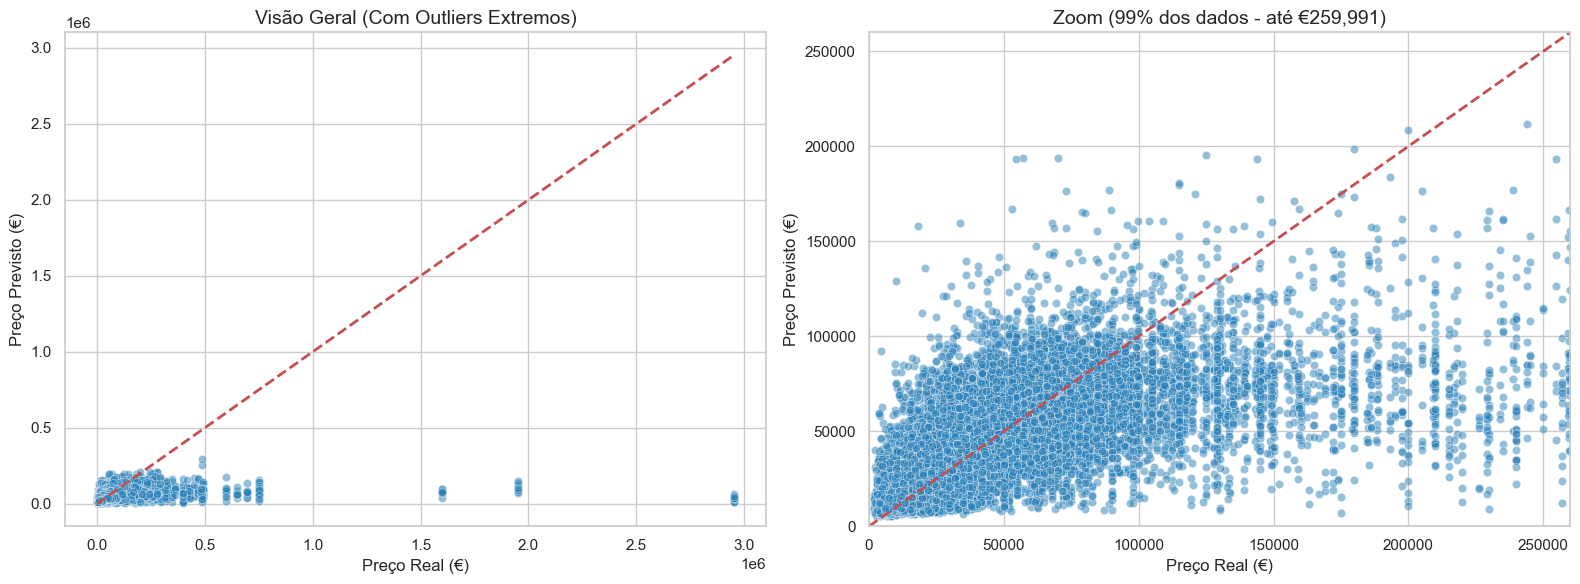

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Preparar os dados (reverter a escala logarítmica)
# Verifica se y_val é uma série Pandas ou array numpy para evitar erros
y_real = np.expm1(y_val.values) if hasattr(y_val, 'values') else np.expm1(y_val)
y_pred = np.expm1(val_predictions)

# Criar um DataFrame temporário para facilitar a visualização
df_results = pd.DataFrame({'Real': y_real, 'Previsto': y_pred})

# 2. Configurar o gráfico (Criamos 2 gráficos lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# --- GRÁFICO 1: Visão Geral (inclui os outliers milionários) ---
sns.scatterplot(data=df_results, x='Real', y='Previsto', alpha=0.5, color='#2980b9', ax=axes[0])
# Linha de referência (ideal)
max_val = max(df_results['Real'].max(), df_results['Previsto'].max())
axes[0].plot([0, max_val], [0, max_val], '--r', linewidth=2, label='Ideal')
axes[0].set_title('Visão Geral (Com Outliers Extremos)', fontsize=14)
axes[0].set_xlabel('Preço Real (€)')
axes[0].set_ylabel('Preço Previsto (€)')

# --- GRÁFICO 2: Zoom (Foco nos carros "normais") ---
# Focamos em 99% dos dados para ignorar os outliers extremos que distorcem o gráfico
limite_visual = np.percentile(y_real, 99) 

sns.scatterplot(data=df_results, x='Real', y='Previsto', alpha=0.5, color='#2980b9', ax=axes[1])
axes[1].plot([0, limite_visual], [0, limite_visual], '--r', linewidth=2, label='Ideal')

# Forçar os limites dos eixos para fazer o "Zoom"
axes[1].set_xlim(0, limite_visual)
axes[1].set_ylim(0, limite_visual)
axes[1].set_title(f'Zoom (99% dos dados - até €{limite_visual:,.0f})', fontsize=14)
axes[1].set_xlabel('Preço Real (€)')
axes[1].set_ylabel('Preço Previsto (€)')

plt.tight_layout()
plt.show()